In [ ]:
!pip install seaborn --quiet

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

def generate_transactions(n=2777, fraud_ratio=0.07):
    np.random.seed(77)
    transaction_ids = [f'TXN{i:05d}' for i in range(1, n+1)]
    vendors = [f'ООО Logistics_{i}' for i in range(1,20)] + [f'ООО Office_{i}' for i in range(1,33)] + [f'ООО Distributor_{i}' for i in range(1, 45)]
    ghost_vendors = [f'ООО Фантом_{i}' for i in range(1, 6)]
    employees = [f'EMP_{i:03d}' for i in range(1, 21)]
    categories = ['IT service', 'Marceting', 'Logistics', 'Consulting', 'Office expenses']
    data = []
    start_date = datetime(2024, 1, 1)
    for i in range(n):
        date = start_date + timedelta(days=random.randint(0, 180))
        hour = np.random.choice(range(9, 19))
        amount = int(np.random.normal(30000, 1000))
        vendor = random.choice(vendors)
        employee = random.choice(employees)
        category = random.choice(categories)
        data.append([transaction_ids[i], amount, vendor, date.date(), hour, employee, category, 0])
    df = pd.DataFrame(data, columns=['transaction_id', 'amount', 'vendor', 'date', 'hour', 'employee_id', 'category', 'is_fraud'])
    fraud_count = int(n * fraud_ratio)
    fraud_indices = np.random.choice(df.index, fraud_count, replace=False)
    for idx in fraud_indices:
        fraud_type = np.random.choice(['high_amount', 'round_amount', 'night', 'weekend', 'duplicate', 'ghost_vendor','sequential', 'unusual_combo'],p=[0.15, 0.15, 0.15, 0.10, 0.15, 0.15, 0.10, 0.05])
        if fraud_type == 'high_amount': df.at[idx, 'amount'] = random.choice([150000, 250000, 500000])
        elif fraud_type == 'round_amount': df.at[idx, 'amount'] = random.choice([50000, 100000, 250000])
        elif fraud_type == 'night': df.at[idx, 'hour'] = random.choice([0,1,2,3,4,23])
        elif fraud_type == 'weekend': df.at[idx, 'date'] = df.at[idx, 'date'] + timedelta(days=(5 - df.at[idx, 'date'].weekday()) % 7)
        elif fraud_type == 'duplicate': duplicate_row = df.sample(1).iloc[0]; df.at[idx, 'amount'] = duplicate_row['amount']; df.at[idx, 'vendor'] = duplicate_row['vendor']
        elif fraud_type == 'ghost_vendor': df.at[idx, 'vendor'] = f'ООО Фантом_{random.randint(1,5)}'
        elif fraud_type == 'sequential': df.at[idx, 'hour'] = random.randint(0, 23); df.at[idx, 'amount'] = int(df.at[idx, 'amount'] * random.uniform(1.5, 3.0))
        elif fraud_type == 'unusual_combo': df.at[idx, 'category'] = 'Офисные расходы'; df.at[idx, 'amount'] = random.choice([100000, 150000, 200000])
        df.at[idx, 'is_fraud'] = 1
    return df
transactions = generate_transactions()
transactions.to_csv('transactions.csv', index=False)
transactions.head()

,transaction_id,amount,vendor,date,hour,employee_id,category,is_fraud
0,TXN00001,48913,ООО Office_10,2024-06-10,4,EMP_006,Consulting,1
1,TXN00002,29729,ООО Office_1,2024-05-12,14,EMP_014,Office expenses,0
2,TXN00003,29445,ООО Office_8,2024-06-02,17,EMP_016,IT service,0
3,TXN00004,31076,ООО Distributor_41,2024-04-05,14,EMP_006,Logistics,0
4,TXN00005,28416,ООО Office_22,2024-03-03,12,EMP_002,Logistics,0


In [ ]:
def create_features(df):
    df_feat = df.copy()
    df_feat['date'] = pd.to_datetime(df_feat['date']) # Moved to the beginning
    df_feat['log_amount'] = np.log1p(df_feat['amount'])
    df_feat['sqrt_amount'] = np.sqrt(df_feat['amount'])
    df_feat['month'] = df_feat['date'].dt.month
    df_feat['quarter'] = df_feat['date'].dt.quarter
    df_feat['is_business_hours'] = ((df_feat['hour'] >= 9) & (df_feat['hour'] <= 18)).astype(int)
    df_feat['day_of_week'] = df_feat['date'].dt.dayofweek
    df_feat['is_night'] = df_feat['hour'].apply(lambda x: 1 if (x >= 22 or x <= 6) else 0)
    df_feat['is_weekend'] = df_feat['date'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)
    vendor_counts = df_feat['vendor'].value_counts()
    df_feat['vendor_freq'] = df_feat['vendor'].map(vendor_counts) / len(df_feat)
    df_feat['round_amount'] = df_feat['amount'].apply(lambda x: 1 if x in [50000, 100000, 250000] else 0)
    emp_counts = df_feat['employee_id'].value_counts()
    df_feat['employee_load'] = df_feat['employee_id'].map(emp_counts) / len(df_feat)
    df_feat['amount_zscore'] = (df_feat['amount'] - df_feat['amount'].mean()) / df_feat['amount'].std()
    df_feat['amount_percentile'] = df_feat['amount'].rank(pct=True)
    df_feat['employee_freq'] = df_feat.groupby('employee_id')['employee_id'].transform('count') / len(df_feat)
    df_feat['vendor_freq'] = df_feat.groupby('vendor')['vendor'].transform('count') / len(df_feat)
    vendor_stats = df_feat.groupby('vendor')['amount'].agg(
        [('vendor_mean_amount', 'mean'),
        ('vendor_count', 'count'),
        ('vendor_total_amount', 'sum'),
        ('vendor_std_amount', 'std')]
    ).reset_index()
    df_feat = df_feat.merge(vendor_stats, on='vendor', how='left')
    df_feat['is_single_transaction_vendor'] = (df_feat['vendor_count'] == 1).astype(int)
    df_feat['weekend_night'] = df_feat['is_weekend'] * df_feat['is_night']
    feature_columns = ['log_amount','hour','is_night','is_weekend','vendor_freq','round_amount','employee_load']
    X = df_feat[feature_columns]
    y = df_feat['is_fraud']
    return X, y, df_feat
X, y, df_feat = create_features(transactions)
X.head(-1)

,log_amount,hour,is_night,is_weekend,vendor_freq,round_amount,employee_load
0,10.797819,4,1,0,0.007562,0,0.057976
1,10.299912,14,0,1,0.007562,0,0.048254
2,10.290313,17,0,1,0.009363,0,0.042492
3,10.344223,14,0,0,0.012964,0,0.057976
4,10.254743,12,0,1,0.011523,0,0.052935
...,...,...,...,...,...,...,...
2771,10.311716,13,0,1,0.010803,0,0.050774
2772,10.275396,9,0,1,0.010083,0,0.052215
2773,10.344867,18,0,0,0.010803,0,0.057616
2774,10.307218,18,0,0,0.010443,0,0.057616


In [ ]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)
print(f"Transactions amount: {len(transactions)}")
print(f"Data period: {transactions['date'].min()} - {transactions['date'].max()}")
print(transactions.describe())
amount_stats = transactions.groupby('is_fraud')['amount'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print(amount_stats)

EXPLORATORY DATA ANALYSIS (EDA)
Transactions amount: 2777
Data period: 2024-01-01 - 2024-06-29
              amount         hour     is_fraud
count    2777.000000  2777.000000  2777.000000
mean    35044.769175    13.397191     0.069860
std     36284.026391     3.164379     0.254956
min     26286.000000     0.000000     0.000000
25%     29344.000000    11.000000     0.000000
50%     30043.000000    14.000000     0.000000
75%     30694.000000    16.000000     0.000000
max    500000.000000    23.000000     1.000000
          count           mean   median            std    min     max
is_fraud                                                             
0          2583   29979.902052  29981.0    1001.902990  26286   33767
1           194  102480.603093  31006.0  118356.685241  28296  500000


In [ ]:
night_transactions = transactions[(transactions['hour'] >= 22) | (transactions['hour'] <= 6)]
print(f"Night transactions: {len(night_transactions)}")
rare_vendors = transactions['vendor'].value_counts()
rare_vendors = rare_vendors[rare_vendors <= 3]
print(f"Rare vendors: {len(rare_vendors)}")
correlation = transactions[['amount', 'hour', 'is_fraud']].corr()
print(correlation)

Night transactions: 39
Rare vendors: 1
            amount      hour  is_fraud
amount    1.000000  0.013889  0.509439
hour      0.013889  1.000000 -0.087986
is_fraud  0.509439 -0.087986  1.000000


In [1]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
exclude_columns = ['transaction_id', 'vendor', 'date', 'employee_id', 'category', 'is_fraud']
feature_columns = [col for col in df_feat.columns if col not in exclude_columns]
X = df_feat[feature_columns]
y = df_feat['is_fraud']
print(f"Размер матрицы признаков: {X.shape}")
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

results = {}
print("\n" + "="*80)
print("МОДЕЛЬ 1: ISOLATION FOREST")
print("="*80)
iso_forest = IsolationForest(n_estimators=100,contamination=0.08)
iso_predictions = iso_forest.fit_predict(X_scaled)
iso_predictions = (iso_predictions == -1).astype(int)
iso_scores = -iso_forest.score_samples(X_scaled)
print("classification_report isolation forest")
print(classification_report(y, iso_predictions, target_names=['Normal', 'Fraud']))
results['Isolation Forest'] = {'predictions': iso_predictions,'scores': iso_scores,'accuracy': accuracy_score(y, iso_predictions),'precision': precision_score(y, iso_predictions),'recall': recall_score(y, iso_predictions),'f1': f1_score(y, iso_predictions)}

NameError: name 'df_feat' is not defined

In [ ]:
from operator import neg
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.08)
lof_predictions = lof.fit_predict(X_scaled)
lof_predictions = (lof_predictions == -1).astype(int)
lof_scores = -lof.negative_outlier_factor_
print("classification_report LOF")
print(classification_report(y, lof_predictions, target_names=['Normal', 'Fraud']))
results['LOF'] = {'predictions': lof_predictions,'scores': lof_scores,'accuracy': accuracy_score(y, lof_predictions),'precision': precision_score(y, lof_predictions),'recall': recall_score(y, lof_predictions),'f1': f1_score(y, lof_predictions)
}
ocsvm = OneClassSVM(kernel='rbf',gamma='auto',nu=0.08)
ocsvm_predictions = ocsvm.fit_predict(X_scaled)
ocsvm_predictions = (ocsvm_predictions == -1).astype(int)
ocsvm_scores = -ocsvm.decision_function(X_scaled)
print("classification_report one class svm")
print(classification_report(y, ocsvm_predictions, target_names=['Normal', 'Fraud']))
results['One-Class SVM'] = {'predictions': ocsvm_predictions,'scores': ocsvm_scores,'accuracy': accuracy_score(y, ocsvm_predictions),'precision': precision_score(y, ocsvm_predictions),'recall': recall_score(y, ocsvm_predictions),'f1': f1_score(y, ocsvm_predictions)}

comparison_df = pd.DataFrame({'Model': list(results.keys()),'Accuracy': [results[m]['accuracy'] for m in results],'Precision': [results[m]['precision'] for m in results],'Recall': [results[m]['recall'] for m in results],'F1-Score': [results[m]['f1'] for m in results]
}).round(4)

print(comparison_df.to_string(index=False))
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_model_name
best_predictions = results[best_model_name]['predictions']
best_scores = results[best_model_name]['scores']
df_feat['model_prediction'] = best_predictions
df_feat['anomaly_score'] = best_scores
anomaly_scores=-lof.negative_outlier_factor_
risk_score=100*(anomaly_scores-anomaly_scores.min())/(anomaly_scores.max()-anomaly_scores.min())
def classify_risk_level(score):
  if score >=80: return 'High Risk'
  elif score >=50: return 'Medium Risk'
  else: return 'low Risk'
df_feat['model_flag']=best_predictions
df_feat['risk_score'] = risk_score
df_feat['risk_level'] = df_feat['risk_score'].apply(classify_risk_level)
df_feat


Model 2: LOCAL OUTLIER FACTOR (LOF)
classification_report
              precision    recall  f1-score   support

      Normal       0.95      0.94      0.95      2583
       Fraud       0.35      0.41      0.38       194

    accuracy                           0.91      2777
   macro avg       0.65      0.68      0.66      2777
weighted avg       0.91      0.91      0.91      2777

classification_report:
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.97      2583
       Fraud       0.59      0.67      0.62       194

    accuracy                           0.94      2777
   macro avg       0.78      0.82      0.80      2777
weighted avg       0.95      0.94      0.95      2777

           Model  Accuracy  Precision  Recall  F1-Score
Isolation Forest    0.9420     0.5740  0.6598    0.6139
             LOF    0.9067     0.3543  0.4072    0.3789
   One-Class SVM    0.9438     0.5856  0.6701    0.6250


,transaction_id,amount,vendor,date,hour,employee_id,category,is_fraud,log_amount,sqrt_amount,...,vendor_count,vendor_total_amount,vendor_std_amount,is_single_transaction_vendor,weekend_night,model_prediction,anomaly_score,model_flag,risk_score,risk_level
0,TXN00001,48913,ООО Office_10,2024-06-10,4,EMP_006,Consulting,1,10.797819,221.162836,...,21,824364,37061.616883,0,0,1,11.509289,1,1.179183,low Risk
1,TXN00002,29729,ООО Office_1,2024-05-12,14,EMP_014,Office expenses,0,10.299912,172.420996,...,21,626048,1050.592910,0,0,0,-4.526886,0,1.007627,low Risk
2,TXN00003,29445,ООО Office_8,2024-06-02,17,EMP_016,IT service,0,10.290313,171.595454,...,26,776328,1081.074477,0,0,1,0.198995,1,2.790164,low Risk
3,TXN00004,31076,ООО Distributor_41,2024-04-05,14,EMP_006,Logistics,0,10.344223,176.283862,...,36,1188945,20069.139135,0,0,0,-3.879605,0,3.862487,low Risk
4,TXN00005,28416,ООО Office_22,2024-03-03,12,EMP_002,Logistics,0,10.254743,168.570460,...,32,954614,953.542984,0,0,0,-3.557566,0,1.047807,low Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2772,TXN02773,29009,ООО Office_18,2024-05-04,9,EMP_011,Consulting,0,10.275396,170.320287,...,28,1054141,41628.889857,0,0,0,-4.642848,0,1.300611,low Risk
2773,TXN02774,31096,ООО Distributor_17,2024-01-16,18,EMP_012,Logistics,0,10.344867,176.340580,...,30,903779,956.546680,0,0,1,0.000052,1,4.119369,low Risk
2774,TXN02775,29947,ООО Distributor_26,2024-05-31,18,EMP_012,Logistics,0,10.307218,173.052015,...,29,986619,22322.990211,0,0,0,-4.109462,0,3.155502,low Risk
2775,TXN02776,28919,ООО Distributor_44,2024-06-22,9,EMP_015,Marceting,1,10.272289,170.055873,...,32,962744,932.586794,0,0,0,-1.697683,0,1.091630,low Risk


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 100))
risk_scores = scaler.fit_transform(best_scores.reshape(-1, 1)).flatten()
df_feat['base_risk_score'] = risk_scores
df_feat['risk_bonus'] = 0
df_feat.loc[df_feat['is_night'] == 1, 'risk_bonus'] += 10
df_feat.loc[df_feat['is_weekend'] == 1, 'risk_bonus'] += 5
df_feat.loc[df_feat['round_amount'] == 1, 'risk_bonus'] += 15
df_feat.loc[df_feat['amount_zscore'] > 2, 'risk_bonus'] += 15
df_feat['risk_score'] = np.minimum(
    df_feat['base_risk_score'] + df_feat['risk_bonus'],
    100
)
print(f"  average bonus: {df_feat['risk_bonus'].mean():.2f}")
print(f"  max bonus: {df_feat['risk_bonus'].max():.0f}")
print(f"  bonus transactions> 0: {(df_feat['risk_bonus'] > 0).sum()}")
def classify_risk_level(score):
  if score >=80: return 'High Risk'
  elif score >=50: return 'Medium Risk'
  else: return 'low Risk'
df_feat['risk_level'] = df_feat['risk_score'].apply(classify_risk_level)
risk_distribution = df_feat['risk_level'].value_counts()
print(risk_distribution)
print(f"In percentage")
for level in ['High Risk', 'Medium Risk', 'Low Risk']:
    count = risk_distribution.get(level, 0)
    pct = count / len(df_feat) * 100
    print(f"  {level}: {count} transactions ({pct:.1f}%)")
df_feat['model_flag']=best_predictions
df_feat['risk_score'] = risk_score
df_feat['risk_level'] = df_feat['risk_score'].apply(classify_risk_level)
df_feat
top_10 = df_feat.nlargest(10, 'risk_score')
print(top_10[['transaction_id', 'amount', 'vendor', 'risk_score', 'is_fraud']])

  average bonus: 2.04
  max bonus: 35
  bonus transactions> 0: 835
risk_level
low Risk       2645
High Risk        85
Medium Risk      47
Name: count, dtype: int64
In percentage
  High Risk: 85 транзакций (3.1%)
  Medium Risk: 47 транзакций (1.7%)
  Low Risk: 0 транзакций (0.0%)
     transaction_id  amount              vendor  risk_score  is_fraud
416        TXN00417   69378        ООО Office_9  100.000000         1
2671       TXN02672   82745       ООО Office_15   72.585550         1
1143       TXN01144   50000  ООО Distributor_39   45.704598         1
2309       TXN02310   50000  ООО Distributor_34   34.736237         1
1250       TXN01251   50000    ООО Logistics_10   34.677755         1
1302       TXN01303   75127  ООО Distributor_35   31.123167         1
1614       TXN01615   72972     ООО Logistics_8   29.419195         1
1085       TXN01086  500000   ООО Distributor_2   28.072710         1
730        TXN00731   75615  ООО Distributor_18   27.037744         1
504        TXN00505 

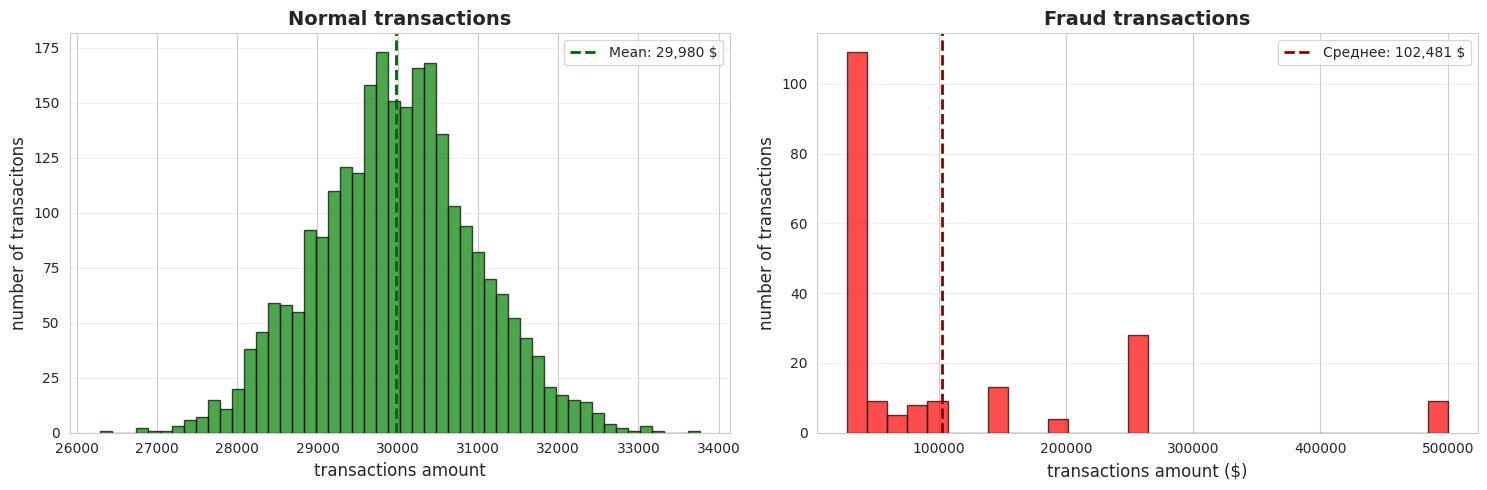

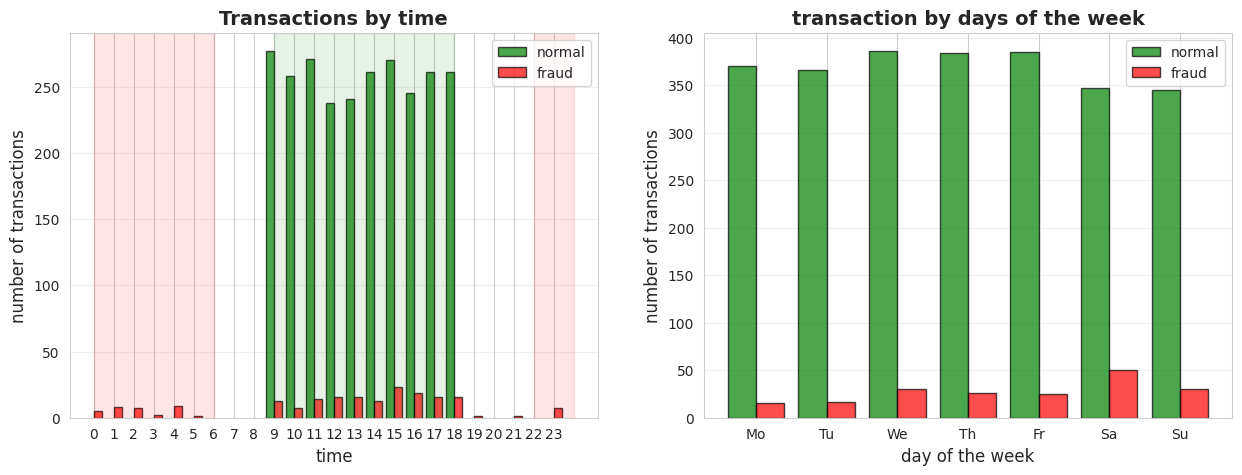

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
normal_amounts = df_feat[df_feat['is_fraud']==0]['amount']
axes[0].hist(normal_amounts, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0].set_title('Normal transactions',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('transactions amount', fontsize=12)
axes[0].set_ylabel('number of transacitons', fontsize=12)
mean_normal = normal_amounts.mean()
axes[0].axvline(mean_normal, color='darkgreen', linestyle='--', linewidth=2,
                label=f'Mean: {mean_normal:,.0f} $')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
fraud_amounts = df_feat[df_feat['is_fraud']==1]['amount']
axes[1].hist(fraud_amounts, bins=30, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Fraud transactions',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('transactions amount ($)', fontsize=12)
axes[1].set_ylabel('number of transactions', fontsize=12)

mean_fraud = fraud_amounts.mean()
axes[1].axvline(mean_fraud, color='darkred', linestyle='--', linewidth=2,
                label=f'mean: {mean_fraud:,.0f} $')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz1_amount_distribution.png', dpi=300, bbox_inches='tight')
plt.show()





fig, axes = plt.subplots(1, 2, figsize=(15, 5))
hourly_fraud = df_feat[df_feat['is_fraud']==1].groupby('hour').size()
hourly_normal = df_feat[df_feat['is_fraud']==0].groupby('hour').size()
x = np.arange(24)
width = 0.4
axes[0].bar(hourly_normal.index - width/2, hourly_normal.values,
            width, alpha=0.7, color='green', label='normal', edgecolor='black')
axes[0].bar(hourly_fraud.index + width/2, hourly_fraud.values,
            width, alpha=0.7, color='red', label='fraud', edgecolor='black')
axes[0].set_title('Transactions by time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('time', fontsize=12)
axes[0].set_ylabel('number of transactions', fontsize=12)
axes[0].set_xticks(x)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvspan(0, 6, alpha=0.1, color='red', label='Night')
axes[0].axvspan(9, 18, alpha=0.1, color='green', label='Work time')
axes[0].axvspan(22, 24, alpha=0.1, color='red')






day_names = ['Mo', 'Tu', 'We', 'Th', 'Fr', 'Sa', 'Su']
daily_fraud = df_feat[df_feat['is_fraud']==1].groupby('day_of_week').size()
daily_normal = df_feat[df_feat['is_fraud']==0].groupby('day_of_week').size()
x_days = np.arange(7)
axes[1].bar(x_days - width/2,
            [daily_normal.get(i, 0) for i in range(7)],
            width, alpha=0.7, color='green', label='normal', edgecolor='black')
axes[1].bar(x_days + width/2,
            [daily_fraud.get(i, 0) for i in range(7)],
            width, alpha=0.7, color='red', label='fraud', edgecolor='black')
axes[1].set_title('transaction by days of the week',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('day of the week', fontsize=12)
axes[1].set_ylabel('number of transactions', fontsize=12)
axes[1].set_xticks(x_days)
axes[1].set_xticklabels(day_names)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

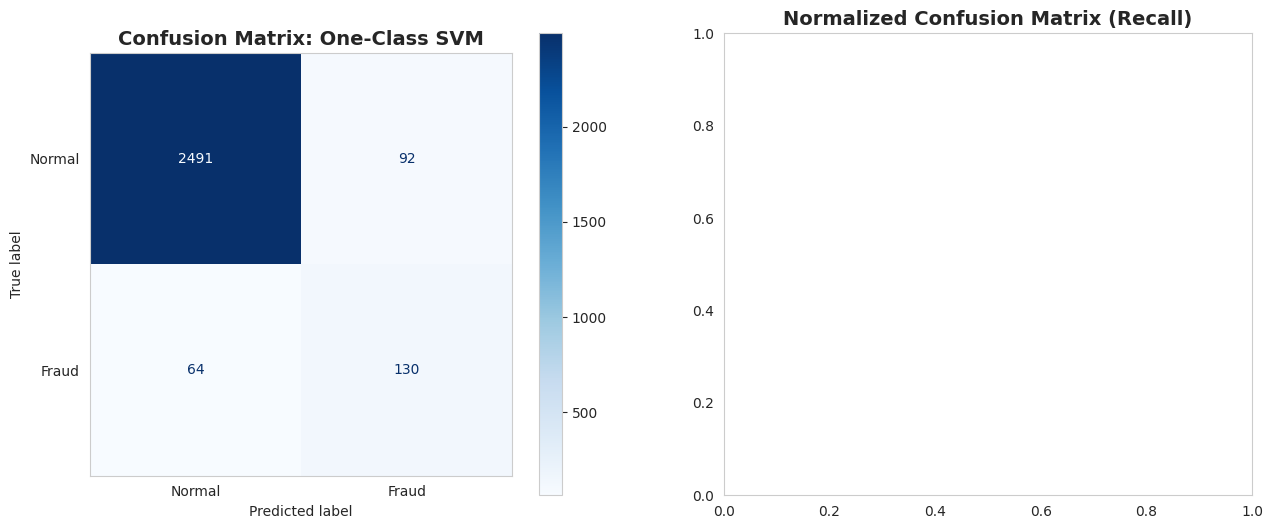

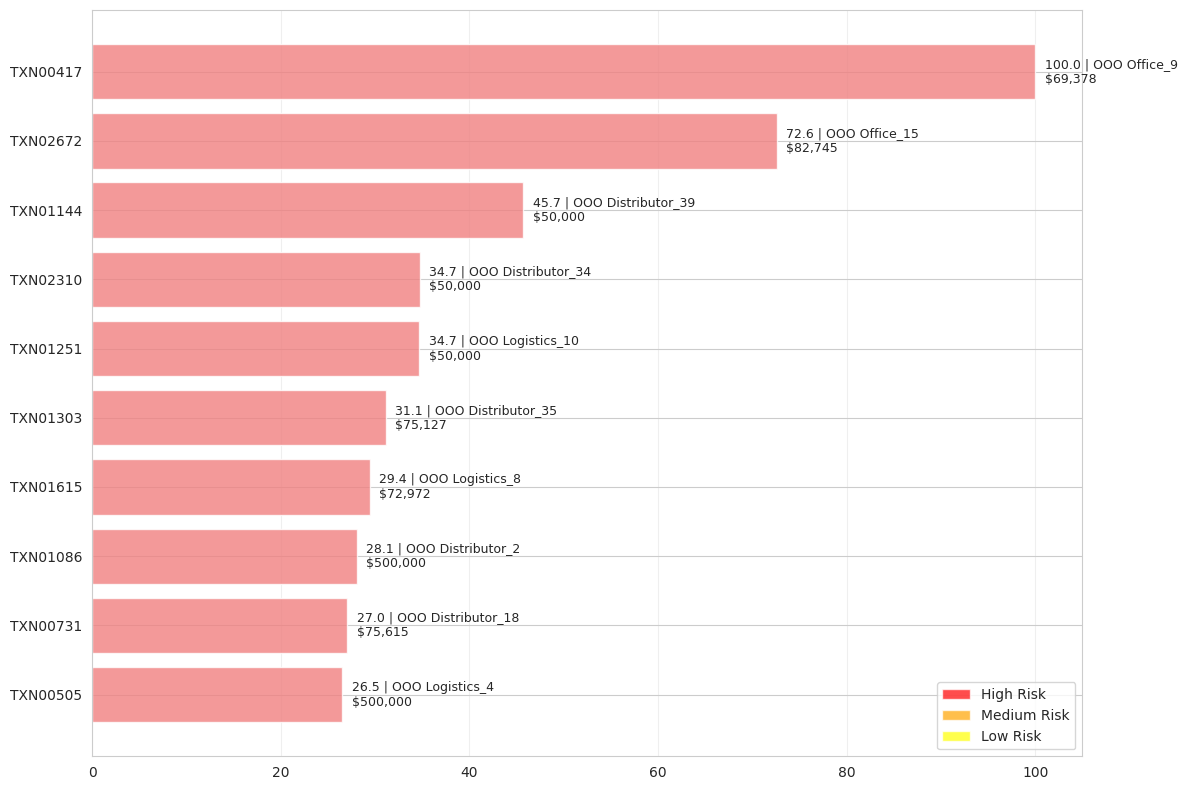

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cm = confusion_matrix(y, best_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Fraud'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Confusion Matrix: {best_model_name}',
                  fontsize=14, fontweight='bold')
axes[0].grid(False)
cm_normalized = confusion_matrix(y, best_predictions, normalize='true')
axes[1].set_title('Normalized Confusion Matrix (Recall)',
                  fontsize=14, fontweight='bold')
axes[1].grid(False)
tn, fp, fn, tp = cm.ravel()
top_suspicious = df_feat.nlargest(10, 'risk_score')[[
    'transaction_id', 'amount', 'vendor', 'risk_score', 'risk_level'
]]

fig, ax = plt.subplots(figsize=(12, 8))
ax.invert_yaxis()
bars = ax.barh(top_suspicious['transaction_id'], top_suspicious['risk_score'], color='lightcoral', alpha=0.8)
for i, (bar, (idx, row)) in enumerate(zip(bars, top_suspicious.iterrows())):
    width = bar.get_width()
    vendor_short = row['vendor'][:20] + '...' if len(row['vendor']) > 20 else row['vendor']
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
            f"{width:.1f} | {vendor_short}\n${row['amount']:,.0f}",
            ha='left', va='center', fontsize=9)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.7, label='High Risk'),
    Patch(facecolor='orange', alpha=0.7, label='Medium Risk'),
    Patch(facecolor='yellow', alpha=0.7, label='Low Risk')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('viz4_top_suspicious.png', dpi=300, bbox_inches='tight')
plt.show()

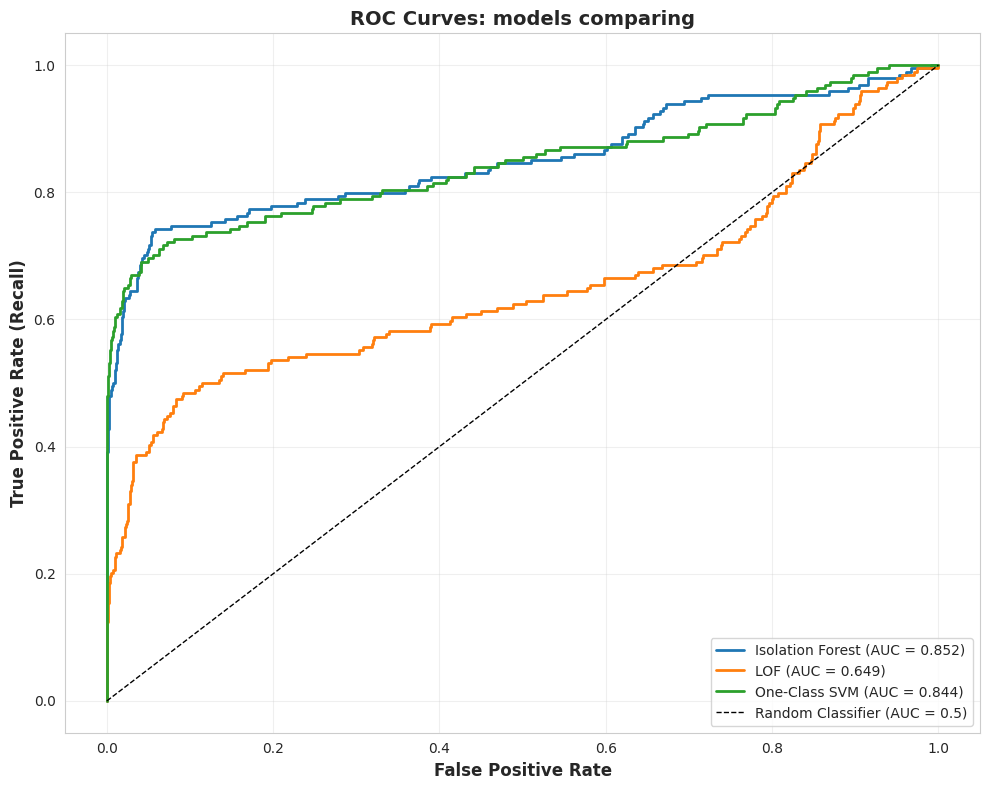

In [ ]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 8))
for model_name, model_data in results.items():
    from sklearn.preprocessing import MinMaxScaler
    scores_normalized = MinMaxScaler().fit_transform(
        model_data['scores'].reshape(-1, 1)
    ).flatten()
    fpr, tpr, thresholds = roc_curve(y, scores_normalized)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves: models comparing', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('viz5_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def generate_suspicious_report(df):
    report = df[df['risk_level']!='Low Risk'].copy()
    def reason(row):
        reasons = []
        if row['is_night']==1: reasons.append('Night transaction')
        if row['is_weekend']==1: reasons.append('Weekend')
        if row['round_amount']==1: reasons.append('Round amount')
        if row['vendor_freq']<0.01: reasons.append('Rare vendor')
        if row['log_amount']>df['log_amount'].quantile(0.95): reasons.append('Unusually large amount')
        return ', '.join(reasons)
    report['fraud_indicators'] = report.apply(reason, axis=1)
    report['recommended_action'] = report['risk_level'].apply(lambda x: 'Immediate audit' if x=='High Risk' else 'Review')
    report.to_csv('suspicious_transactions.csv', index=False)
    return report

suspicious_report = generate_suspicious_report(df_feat)
suspicious_report.head()

,transaction_id,amount,vendor,date,hour,employee_id,category,is_fraud,log_amount,sqrt_amount,...,weekend_night,model_prediction,anomaly_score,model_flag,risk_score,risk_level,base_risk_score,risk_bonus,fraud_indicators,recommended_action
0,TXN00001,48913,ООО Office_10,2024-06-10,4,EMP_006,Consulting,1,10.797819,221.162836,...,0,1,11.509289,1,1.179183,low Risk,85.978633,10,"Night transaction, Rare vendor, Unusually larg...",Review
1,TXN00002,29729,ООО Office_1,2024-05-12,14,EMP_014,Office expenses,0,10.299912,172.420996,...,0,0,-4.526886,0,1.007627,low Risk,21.473556,5,"Weekend, Rare vendor",Review
2,TXN00003,29445,ООО Office_8,2024-06-02,17,EMP_016,IT service,0,10.290313,171.595454,...,0,1,0.198995,1,2.790164,low Risk,40.483286,5,"Weekend, Rare vendor",Review
3,TXN00004,31076,ООО Distributor_41,2024-04-05,14,EMP_006,Logistics,0,10.344223,176.283862,...,0,0,-3.879605,0,3.862487,low Risk,24.077227,0,,Review
4,TXN00005,28416,ООО Office_22,2024-03-03,12,EMP_002,Logistics,0,10.254743,168.570460,...,0,0,-3.557566,0,1.047807,low Risk,25.372621,5,Weekend,Review
